In [2]:
from hdm_actr import oscillators, hrr
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, expon, geom, hypergeom, poisson
from math import isclose
from hdm_actr.oscillators import TimeVector
from hdm_actr.hrr import HRR
import os
import itertools
from tqdm.contrib.itertools import product as tqdm_product
import json
from datetime import datetime
import socket

/Users/meeraray/PyEnvs/actr/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Here we import the script which opens a connection to ACT-R with a HDM as its memory module. Make sure you have ACT-R up and running in Lisp before you run this.

In [ ]:
import hdm_actr.hdm_actr

If everything is set up correctly, above it should say "ACT-R connection has been started." 

# Running a Test Model

In [ ]:
hdm_actr.actr.load_act_r_model("test.lisp")

In [4]:
# path relative to where ACT-R is running, not here
# hdm_actr.actr.load_act_r_model("test.lisp")
hdm_actr.actr.run(1)

[0.3, 26, None]

In [5]:
hdm_actr.actr.reset()
hdm_actr.actr.reload()
hdm_actr.actr.run(1)

[0.25, 16, None]

# Parse Testing

In [6]:
from hdm_actr.hdm_actr import LispArgParser

In [7]:
 # TODO: maybe LispArgParser method to eliminate redundancy below?
from enum import Enum
class Option(Enum):
        GET = 1
parser = LispArgParser(prog="params")
parser.add_argument("--lf", nargs="?", const=Option.GET, type=float)
parser.add_argument("--esc", nargs="?", const=Option.GET, type=bool)
parser.add_argument("--hdm-v", nargs="?",  const=Option.GET, type=bool)

_StoreAction(option_strings=['--hdm-v'], dest='hdm_v', nargs='?', const=<Option.GET: 1>, default=None, type=<class 'bool'>, choices=None, required=False, help=None, metavar=None)

In [18]:
parser.parse_args(['--esc', ''])

Namespace(lf=None, esc=False, hdm_v=None)

To reload HDM, `(quit)` Lisp and restart your kernel.

# Corpus Debugging

In [ ]:
with open("hdm_actr/corpora/sample_text.txt", mode="r", encoding="utf-16") as f:
    for line in f:
        print(line[:10])

In [4]:
hdm_actr.hdm_actr.preprocess_text("hdm_actr/corpora/sample_text.txt", "hdm_actr/corpora/sample_out.txt", "utf-16")

hdm_actr\corpora\sample_text.txt


In [ ]:
hdm_actr.hdm_actr.read_corpus_hdm("hdm_actr/corpora/sample_out.txt", "utf-16")

Take HDM vectors from currently running HDM model and print PCA plot

In [51]:
deja_terms = "blackness, black, African, crime, police, urban, america, predictive, AI"
deja_terms = deja_terms.split(",")
deja_terms = [t.lstrip(" ") for t in deja_terms]
print(deja_terms)

['blackness', 'black', 'African', 'crime', 'police', 'urban', 'america', 'predictive', 'AI']


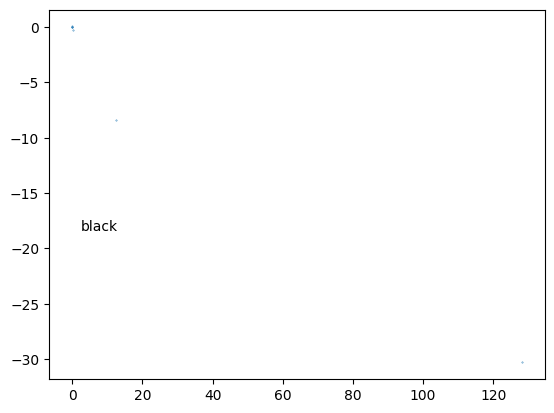

In [63]:
# def print_pca(print_terms):
print_terms = deja_terms
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
mem_vecs = np.vstack([v.v for k, v in hdm_actr.hdm_actr.hdm_modules['test'].mem.items()])
mem_keys = [k for k, v in hdm_actr.hdm_actr.hdm_modules['test'].mem.items()]
mem_vecs = StandardScaler().fit_transform(mem_vecs)
mem_emb = PCA(n_components=2).fit_transform(mem_vecs)
# plt.scatter(mem_emb[:,0], mem_emb[:,1], c="m")
inds = []
labels = []
for i in range(len(mem_keys)):
    # truncate and replace with ... if too long
    if mem_keys[i] in print_terms:
        inds.append(i)
        mem_key = mem_keys[i]

        if len(mem_key) > 10:
            mem_key = mem_key[:7] + "..."
        labels.append(mem_key)
        # plt.annotate(mem_key, (mem_emb[i,0] + 0.15, mem_emb[i,1] + 0.05))

plt.scatter(mem_emb[inds, 0], mem_emb[inds, 1], s=0.1)
for i, l in zip(inds, labels):
    plt.annotate(l, (mem_emb[i,0] - 10, mem_emb[i,1] - 10))
# plt.xlim(-10, 10)
# plt.ylim(-50, 50)
plt.show()

In [ ]:
print(mem_emb[0])
mem_emb[:, 1]
print(np.min())

[-0.12068296 -0.01015032]


array([-0.01015032, -0.01015032, -0.01015032, ..., -0.01015033,
       -0.01015029, -0.01015029])

In [41]:
mem_emb.shape

(54981, 2)

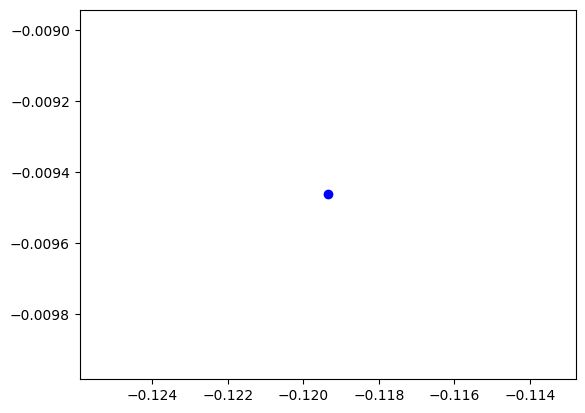

In [27]:
print_pca(["perceptions"])

In [56]:
labels

['percept...', 'black', 'crime']

In [18]:
"perceptions" in hdm_actr.hdm_actr.hdm_modules['test'].mem.keys()

True

# Testing HDM Math

In [21]:
test = hdm_actr.hdm_actr.hdm_modules['test']

In [22]:
test.slot_pulling_approach

'top-n'

In [ ]:
{T:V for (T,V) in test.env.items() if not T.startswith("T_")}

In [ ]:
test.chunk_count
np.dot(test.time_vector.eval(0), test.time_vector.eval(2))

In [ ]:
print(test.getChunkTime(0))
print(test.getChunkTime(1))
np.all(test.getChunkTime(0).v == test.getChunkTime(1).v)

Testing HRR Functions

In [ ]:
hrr = HRR(data=np.arange(4))
hrr2 = HRR(N=15)
print(hrr ** 2)
hrr **= 2
print(hrr)


A, B, C = HRR(N=200), HRR(N=200), HRR(N=200)
print(A)
trace1 = A * B + B*C
print((trace1 * ~A).compare(A), (trace1 * ~A).compare(B), (trace1 * ~A).compare(C))

Calculating HDM's default threshold

In [ ]:
import math
math.sqrt(np.exp(-4.6) / (np.exp(-4.6) + 1))

# Varying HDM Parameters

In [6]:
# takes array of parameter names in lisp form (starting with :) and a 2D array
# of values (or iterator e.g. range(..)) to set each parameter. it runs the
# model with every combination of param vals and logs the output. prints in a
# more human-readable format for debugging (form="readable") or with pipe (|) separated values so
# the output can easily be read into a csv-type format for analysis (form="psv")
def test_params(param_names, params_settings, model_name,
                 lisp_filename=None, filename=None, form="readable"):
    # If form spelled incorrectly, raise an exception
    if not (form == "readable" or form == "psv"):
        raise Exception("form must be 'readable' or 'psv'")
    # Make output filenames 
    if filename is None:
        if form == "readable":
            filename = os.path.join("logs", model_name + "_out.txt")
        elif form == "psv":
            filename = os.path.join("logs", model_name + "_out.csv")
    if lisp_filename is None:
        lisp_filename = model_name + ".lisp"

    # load model
    hdm_actr.actr.load_act_r_model(lisp_filename)
    # get all parameter names at beginning so they can be printed as psv heading
    # and so the values are logged in the corresponding order in each iteration
    par  = hdm_actr.hdm_actr.params("test", argsl=["--get-all-params"])
    pnames = list(par.keys())
    
    # Print model name, date and time, and device to file at the beginning
    with open(filename, "a+") as f:
        d = datetime.now().strftime('%m/%d/%y %I:%M %p')
        device = socket.gethostname().rstrip("local").replace("-", " ").replace(".", "")
        f.write(f"Testing model {model_name} on {d}, running on {device} \n")
        if form == "psv":
            #  print parameter headings in file - leave out : at beginning for convenience
            # headings_str = [p.lstrip(":") for p in param_names]
            headings_str = "|".join(pnames)
            f.write(f"{headings_str}|output\n")
    # hdm_actr.hdm_actr.params("test", [":log-outcomes", filename])
    
    # get all combinations of parameters
    # all_params = itertools.product(*params_settings)
    # i = 0
    for s in tqdm_product(*params_settings): #all_params:
        # make argument-value list for params()
        args = [":log-outcomes", filename]
        for i in range(len(param_names)):
            args.append(param_names[i])
            args.append(s[i])
        args.append("--get-all-params")
        # set all parameters
        params_dict = hdm_actr.hdm_actr.params(model_name, args)
        # write params to file
        with open(filename, "a") as f:
            if form == "readable":
                # Print model name, each parameter name and its set value
                par_str = ", ".join([str(a) for a in args[2:-1]])
                f.write(f"{model_name}, {par_str}, ")
                # for i in range(len(param_names) - 1):
                #     f.write(f"{param_names[i]}, {s[i]}, ") 
                # f.write(f"{param_names[-1]}, {s[-1]}, ")
                # f.write()
            else:
                # Print just parameter settings separated by pipes followed by another pipe to
                # separate it from the chunk output
                log_vals = [params_dict[p] for p in pnames]
                log_vals = [str(v) + "|" for v in log_vals]
                f.write("".join(log_vals))
               
        # run model
        hdm_actr.actr.run(1)
        # next line
        with open(filename, "a") as f:
            f.write("\n")
        # break
        # reset and reload to prep for next iter
        hdm_actr.actr.reset()
        hdm_actr.actr.reload()
        # i += 1

In [7]:
test_params(param_names = [":slot-pulling-approach"],
    form="psv",
    filename = "logs/test4.csv",
    model_name = "test",
    params_settings = [["top-n", "threshold", "top-n-with-threshold"]])

100%|██████████| 3/3 [00:02<00:00,  1.49it/s]


In [8]:
test_params(param_names = [":slot-pulling-approach", ":slot-pulling-threshold", ":slot-pulling-n"],
    filename = "logs/test4.csv",
    model_name = "test",
    form = "psv",
    params_settings = [["top-n", "threshold", "top-n-with-threshold"], [i/10 for i in range(11)], range(5)])

100%|██████████| 165/165 [02:00<00:00,  1.37it/s]


In [8]:
json.loads(input())

{}

Compare the logged chunks with the "correct" ones.

In [13]:
par  = hdm_actr.hdm_actr.params("test", argsl=["--get-all-params"])

input to param is: test with ['--get-all-params']
New arsgl is ['--get-all-params']
params called


In [14]:
list(par.keys())

['lf',
 'esc',
 'hdm_v',
 'hdm_k',
 'pull_slots',
 'time_scale',
 'slot_pulling_threshold',
 'hdm_t',
 'hdm_o',
 'slot_pulling_approach',
 'slot_pulling_n',
 'log_outcomes']

# Time Vector Graphs

In [74]:
TV = TimeVector()
TV.context_thetas[0].shape, TV.context_offsets[0].shape, TV.context_phis[0].shape
# print((np.sin(TV.context_offsets[0] + np.sin(TV.context_phis[0] + 1 * TV.context_thetas[0]))).shape)

[0.18083679 0.14941367 0.12356079 0.10229073 0.08479113 0.07039361
 0.05854827 0.04880271 0.0407847  0.03418801 0.02876068 0.02429543
 0.02062172 0.01759923 0.01511253]


((320,), (320,), (320,))

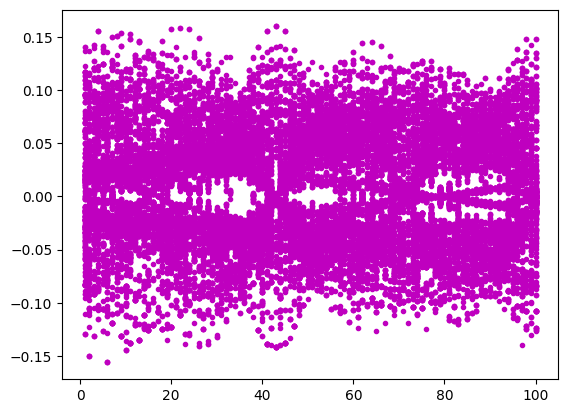

In [6]:
y1 = []
# x_cont = np.linspace(1, 10, 50)
x_disc = np.arange(1, 100+1)
for i in x_disc:
    T = TV.eval(i)
    y1.append(T)
plt.plot(x_disc, y1, "mo", markersize=3)
plt.show()

In [71]:
import numpy as np

In [72]:
y2 = []
x_cont = np.linspace(1, 100, 1000)
for i in x_cont:
    T = TV.eval(i)
    y2.append(T)
plt.plot(x_cont, y2)
plt.show()

NameError: name 'TV' is not defined

In [125]:
def gen_TV_range(TV_kwargs, x_max, x_len):
    TV = TimeVector(**TV_kwargs)
    Y = []
    X = np.linspace(1, x_max, x_len)
    for i in X:
        T = TV.eval(i)
        Y.append(T)
    # print()
    return X, Y

In [126]:
X, Y = gen_TV_range({"seed":22825}, 30, 30)

[0.18083679 0.14941367 0.12356079 0.10229073 0.08479113 0.07039361
 0.05854827 0.04880271 0.0407847  0.03418801 0.02876068 0.02429543
 0.02062172 0.01759923 0.01511253]


In [155]:
import matplotlib.cm

In [164]:
matplotlib.colormaps["plasma"](np.linspace(0, 1, len(Y[0])))

array([[0.050383, 0.029803, 0.527975, 1.      ],
       [0.050383, 0.029803, 0.527975, 1.      ],
       [0.063536, 0.028426, 0.533124, 1.      ],
       ...,
       [0.941896, 0.96859 , 0.140956, 1.      ],
       [0.940015, 0.975158, 0.131326, 1.      ],
       [0.940015, 0.975158, 0.131326, 1.      ]])

In [177]:
def graph(X, Y, cmap="plasma"):
    plt.clf()
    colors = matplotlib.colormaps[cmap](np.linspace(0, 1, len(Y[0])))
    for i in range(len(Y[0])):
        plt.plot(X, [y[i] for y in Y], c=colors[i])
    plt.xlabel("Chunk Index")
    plt.ylabel("Encoding")
    plt.show()

In [184]:
np.arange(320)[0:-1:50]

array([  0,  50, 100, 150, 200, 250, 300])

[0.18083679 0.14941367 0.12356079 0.10229073 0.08479113 0.07039361
 0.05854827 0.04880271 0.0407847  0.03418801 0.02876068 0.02429543
 0.02062172 0.01759923 0.01511253]


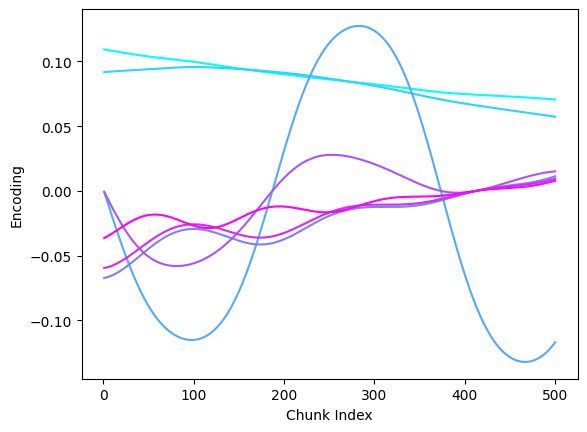

In [181]:
X, Y = gen_TV_range({"scale":5e-6, "seed":22825}, 500, 500)
graph(X, [y[0:-1:50] for y in Y], cmap="cool")

# plt.legend()

## Comparing Similarities

Just taking dot product since time vecs already normalized

In [119]:
def self_sim(x_range, y_range, plot=True):
    assert len(x_range) == len(y_range)
    # sims = []
    for t, V in zip(x_range, y_range):
        sims_t = []
        diff_t = []
        for t2, V2 in zip(x_range, y_range):
        # for t2, V2 in zip(x_disc, y2):
            sims_t.append(np.dot(V, V2))
            diff_t.append(t - t2)
        # print(diff_t)
        if plot:
            plt.plot(diff_t, sims_t, c="m", lw=1)
            plt.xlabel("Separation in Time")
            plt.ylabel("Similarity")
        # plt.plot(diff_t, sims_t, label=f"{t}")
        # sims.append(sims_t)
    # plt.plot(x_cont, sims)
    # plt.vlines(x_cont[20], 0, 30)
# plt.legend()
# plt.show()
# print(np.argmax(np.array(sims)))


In [120]:
def run_self_sim_full(TV_params, x_max, x_step):
    X, Y = gen_TV_range(TV_params, x_max, int(x_max / x_step))
    self_sim(X, Y, plot=True)
    params = {"O_n":15, "T_n":16*20, "scale":10e-5, "osc_avg":5.125}
    for p, v in params.items():
        if p in TV_params.keys():
            v = TV_params[p]
        print(f"{p}: {v}")

[0.18083679 0.14941367 0.12356079 0.10229073 0.08479113 0.07039361
 0.05854827 0.04880271 0.0407847  0.03418801 0.02876068 0.02429543
 0.02062172 0.01759923 0.01511253]
O_n: 15
T_n: 320
scale: 0.0001
osc_avg: 5.125


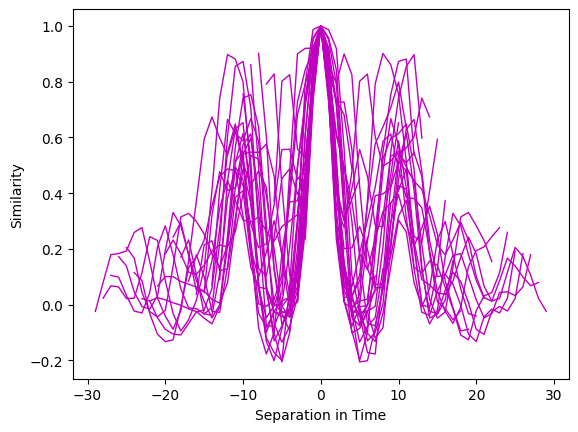

In [125]:
run_self_sim_full({}, 30, 1)

In [28]:
def sim_one(x, x_cont, y2):
    len(y2), y2[0].shape
    sims = []
    # faster way to do this? not on test time so ok to be a bit lazy with vectorizing
    for i,vec in enumerate(y2):
        sims.append(np.dot(y2[x], vec))
    plt.vlines(x_cont[x],
                min(sims) - 0.1*abs(min(sims)),
                1.1 * max(sims), colors='red')
    plt.plot(x_cont, sims, c="pink")
    plt.show()
    print(np.argmax(np.array(sims)))

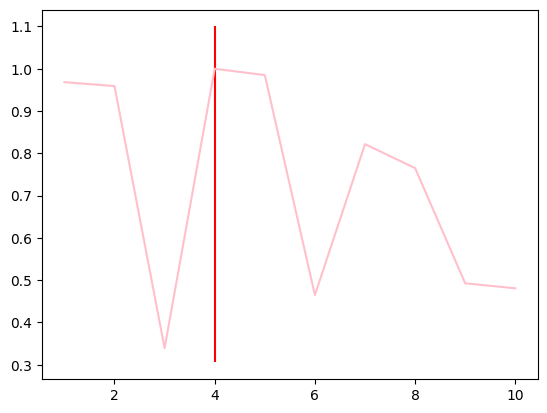

3


In [29]:
sim_one(3, X, Y)

In [ ]:

print(len(y2))
sims = []
# faster way to do this? not on test time so ok to be a bit lazy with vectorizing
# time_subs = np.arange(1, 10000, 10)
y1_arr = np.array(y1)
for t, V in zip(x_disc, y1_arr):
    sims_t = []
    diff_t = []
    for t2, V2 in zip(x_cont, y2):
    # for t2, V2 in zip(x_disc, y2):
        sims_t.append(np.dot(V, V2))
        diff_t.append(t - t2)
    plt.plot(diff_t, sims_t, c="m", lw=1)
    # plt.plot(diff_t, sims_t, label=f"{t}")
    sims.append(sims_t)
# plt.plot(x_cont, sims)
# plt.vlines(x_cont[20], 0, 30)
# plt.legend()
plt.show()
# print(np.argmax(np.array(sims)))

# Trying Different Frequency Functions

In [3]:
(beta.cdf(5, a=1, b=3.5, scale=15) - beta.cdf(4, a=1, b=3.5, scale=15))

0.09579369576863994

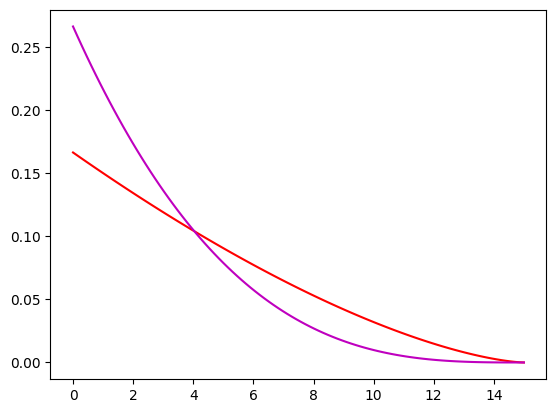

In [4]:
x= np.linspace(0, 15, 100)
plt.plot(x, beta.pdf(x, a=1, b=2.5, scale=15), c="r")
plt.plot(x, beta.pdf(x, a=1, b=4, scale=15), c="m")


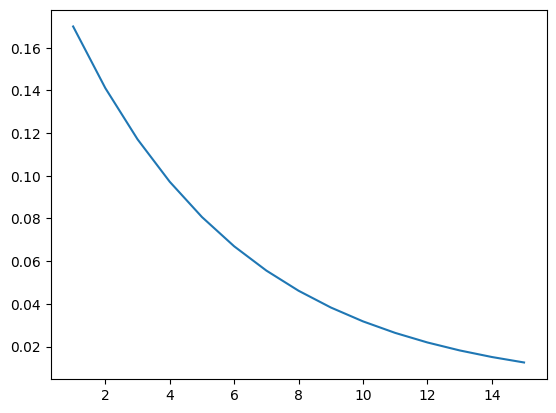

In [5]:
plt.plot(np.arange(1, 16), geom.pmf(np.arange(1, 16), p=0.17))

[0.2        0.16       0.128      0.1024     0.08192    0.065536
 0.0524288  0.04194304 0.03355443 0.02684355 0.02147484 0.01717987
 0.0137439  0.01099512 0.00879609]
[0.15842671 0.1423269  0.12681299 0.11190803 0.09763801 0.08403257
 0.07112595 0.05895831 0.04757766 0.03704286 0.02742841 0.01883308
 0.01139702 0.00534398 0.00114755]
[0.18083679 0.14941367 0.12356079 0.10229073 0.08479113 0.07039361
 0.05854827 0.04880271 0.0407847  0.03418801 0.02876068 0.02429543
 0.02062172 0.01759923 0.01511253]
True


<BarContainer object of 15 artists>

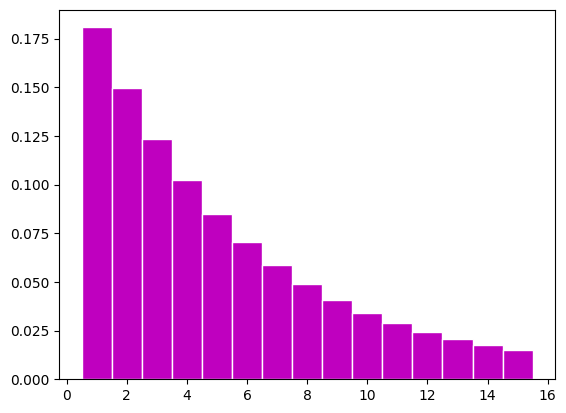

In [6]:
print(geom.cdf(np.arange(1, 16), p=0.2) - geom.cdf(np.arange(0, 15), p=0.2))
print(beta.cdf(np.arange(1, 16), a=1, b=2.5, scale=15) - beta.cdf(np.arange(0, 15), a=1, b=2.5, scale=15))
expon_cdf = expon.cdf(np.arange(1, 16), scale=5.125) - expon.cdf(np.arange(0, 15), scale=5.125) + (1 - expon.cdf(15, scale=5.125))/15
print(expon_cdf)
print(isclose(sum(expon_cdf), 1))
plt.bar(x=np.arange(1, 16), height=expon_cdf, width=1, color="m", edgecolor="w")

In [ ]:
np.arange(0, 15) - np.arange(1, 16)

In [ ]:
expon.shapes